# League of Legends: How Does Optimal Character Choice Affect Win Rate Across Ranks?

Oliver Ng

ECO 590

Spring 2026

## Webscraping LoLalytics

## Part 1: Motivation

League of Legends (LoL) is a massively popular multi-player online game with ~117-135 million monthly players, all competing with one another on either the red, or the blue side. Each player chooses a unique character in what's known as the draft stage. It is at this stage that characters are banned and then chosen in an alternating pattern. LoL has 172 characters to chose from, each with their own strengths and weaknesses. As with any competitive game, a metagame has developed with certain characters being stronger on average compared to other characters. Because of this, these characters naturally become more contested during the drafting phase. LoL also has a ranking system with the lowest rank being Iron and the highest being Challenger with a total of 10 ranks. Reaching the "Apex Ranks" requires a large time commitment to not only learning the game, but to also play the game. To expedite the process, it is a common practice to pick the most "meta" character choices to increase your odds of winning. However a strong character choice does not necessarily translate to strong player skill. Because of this, the choice to pick a strong character may not have as strong of an effect on your win rate if you are not capable of playing the character to its highest potential.

LoLalytics is a website that directly collects data from League's servers and compiles that information across each of the ranks onto its website.

https://lolalytics.com/lol/tierlist/

### Research Questions

1. How much of an effect does meta character choice have on win rate?
2. How much does this effect differ across each of League's rank?

## Part 2: Web-Scraping LoLalytics

In [97]:
# Required Packages
import os 
import pandas as pd
import numpy as np
import time
from time import sleep
import selenium 
from selenium import webdriver

from selenium.webdriver.common.by import By #Allows for selenium to click things 
from selenium.webdriver.chrome.service import Service #https://stackoverflow.com/questions/64717302/deprecationwarning-executable-path-has-been-deprecated-selenium-python
from selenium.webdriver.support import expected_conditions as EC #Allows for more complex code 
from selenium.webdriver.chrome.options import Options #Allows you to change aspects of the browser

# Establish options we can change
chrome_options = Options() 
chrome_options.add_argument("--window-size=1900,1000")

### Using Selenium to Webscrape

LoLalytics has multiple pages of data I need. Each of the pages all follow the same format, which makes using a For loop simple for data collection. This For loop is nested within another For loop which cycles through each of the different ranks. It does this by physically clicking on the page by using the .click() function. Each page takes time to load so I include code to scroll down the page to allow every element to fully load in. If this step was not included, then the code would be unable to search for later elements at the bottom of the page. I use slepe commands to give each element time to load as well.

.click() -> https://www.selenium.dev/documentation/webdriver/elements/interactions/

scrolling -> https://stackoverflow.com/questions/12293158/page-scroll-up-or-down-in-selenium-webdriver-selenium-2-using-java

### Data Specification

Our variable of interest is the Pick Ban Influence (PBI) which measures how competitive a character choice is. The way that LoLalytics calculates it is:

(Average Win Rate of Rank - Average Win Rate of all Ranks)\*100\*Pick Rate/(100-Ban Rate)

The issue is that we are using this as a predictor for rank win rate. If we leave PBI as is, we are bound to have highly correlated results which would not tell us much. Because of this we removed win rate from the PBI, leaving us with the ratio of pick rate and ban rate which still works as a measure for "meta-ness" of a character choice. We accomplished this by dividing PBI by the website's "wrdelta" which is the same as (Average Win Rate of Rank - Average Win Rate of all Ranks).

In [59]:
driver = webdriver.Chrome(options = chrome_options) # establish driver

url = 'https://lolalytics.com/lol/tierlist/' # dataset for each champions
driver.get(url) # Get the url

ranknum=[3, 4, 6, 8, 11, 13, 15, 17, 18, 19] # the element for each rank selection

import time            # importing time package
start=time.time()      # start time

out2 = [] # empty list to convert into dataframe later

for r in ranknum:
    out = [] # empty list for data
    count = 3 # starts at 3 to skip the first 2 which are irrelevant elements
    driver.find_elements(By.XPATH,'/html/body/main/div[1]/div/div/div[3]/div/div/div[1]/img')[0].click() # clicks the rank sort
    time.sleep(2)
    driver.find_elements(By.XPATH,f'/html/body/main/div[1]/div/div/div[3]/div[2]/a[{r}]/div')[0].click() # clicks the rank
    time.sleep(1)
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);") # scrolls to the very bottom of the page to load everything (takes ~20 seconds)
    time.sleep(5) # want to wait 5 seconds to let things load
    driver.execute_script("window.scrollBy(0, -6000);") # scrolls back up to load everything
    for i in range(0,18): # scrolls downs for the next 18 seconds to make sure everything loads
        driver.execute_script("window.scrollBy(0, 320);")
        time.sleep(1)
    driver.execute_script("window.scrollTo(0,0);") # scrolls back to the top of the page to also open up the rank selection menu for once the loop resets
    
    buckets = driver.find_elements(By.XPATH, '/html/body/main/div[6]/div') # creating a bucket of each champion
    del buckets[:2] # removes the first 2 from the list to skip the first 2 which are just the title rows
    
    rank = driver.find_elements(By.XPATH, '/html/body/main/div[1]/div/div/div[3]/div/div/div[2]')[0].text # grabs the rank

    temp1=driver.find_elements(By.XPATH, f'/html/body/main/div[1]/div/div/div[10]/div')[0].text # collects the average win rate for that rank
    rankwr=float(temp1.split('%')[0].split("Rate: ")[1]) # collects the average win rate for that rank

    for bucket in buckets: # runs the below code for every champion in the list
        champion = driver.find_elements(By.XPATH, f'/html/body/main/div[6]/div[{count}]/div[3]/a')[0].text # grabs champion name
        wr = driver.find_elements(By.XPATH, f'/html/body/main/div[6]/div[{count}]/div[6]/div/span')[0].text # grabs win rate
    
        temp2= driver.find_elements(By.XPATH, f'/html/body/main/div[6]/div[{count}]/div[6]/div/span')
        wrdelta= temp2[1].text if len(temp2) > 1 else 0 # checks to see if there is an entry for wrdelta (some are missing on the website)

        pick = driver.find_elements(By.XPATH, f'/html/body/main/div[6]/div[{count}]/div[7]')[0].text # grabs pick rate
        ban = driver.find_elements(By.XPATH, f'/html/body/main/div[6]/div[{count}]/div[8]')[0].text # grabs ban rate
        PBI = driver.find_elements(By.XPATH, f'/html/body/main/div[6]/div[{count}]/div[9]')[0].text # grabs PBI
        lane = driver.find_elements(By.XPATH, f'/html/body/main/div[6]/div[{count}]/div[5]/div/img')[0].get_attribute('alt') # grabs lane
        games = driver.find_elements(By.XPATH, f'/html/body/main/div[6]/div[{count}]/div[10]')[0].text # grabs the number of games

        wr=float(wr) # turned into float for future calculation
        wrdelta=float(wrdelta) # turned into float for future calculation
        PBI=float(PBI) # turned into float for future calculation

        PBIno = PBI if (wr-rankwr) == 0 else PBI/(wr-rankwr) # removes win rate from the PBI
    
        data = {
            'Champion':champion,
            'wr':wr,
            'wrdelta':wrdelta,
            'rankwr':rankwr,
            'Pick Rate':pick,
            'Ban Rate':ban,
            'PBI Index':PBI,
            'PBIno':PBIno,
            'lane':lane,
            'games':games,
            'rank':rank
        }
        out.append(data) # adds champion data to a list that will be added at the end of this for loop
        count+=1
    out2.append(out) # EACH OF THE RANKS'S DATA IS ADDED TO A FINAL LIST THAT CAN BE SLICED TO GRAB EACH SET
    ## EDIT: STILL KEEPING THIS FUNCTION, BUT PUTTING EVERYTHING INTO ONE DATASET INSTEAD OF TEN. STILL KEEPING JUST IN CASE !!!

end=time.time()        # end time

total_time=end-start   # measures total time by subtracting start by end
print(f' The code takes {round(total_time,5)} seconds to run.')

 The code takes 627.73343 seconds to run.


### Converting into a DataFrame & Cleaning

Each of the ranks data are all sorted in the "out2" list. Each entry is a different rank. This was initially done to turn each entry into its own dataset. But I realized that the research project would work better with one large dataset. However, I kept the code like that for posterity's sake. The following code combines the each of the list entries into one large dataframe, that I then convert into a .csv for analysis.

There's not much cleaning at this phase as that was also done during data collection. Most of the data that was collected are just strictly numbers, or names without special characters inside. However I will also add on the difference between the win rate of a champion in an individual rank and the average win rate of that rank. 

I also had to transform the PBIno column to reflect a character win rate performing below the average win rate. We account for this by checking if the wrdiff is negative (below 0), then multiplying the PBIno by -1 if it is. This way we can also see the full, negative extent to which a character is unfavored in the meta. Our games entries are all also objects, not integers. So we have to transform it into integers for calculation.

In [256]:
league=pd.DataFrame() # making an empty dataframe
c=0 # counter
for rank in out2:
    temp = pd.DataFrame(out2[c]) # slicing to turn each entry into a new dataframe to concat later
    league = pd.concat([league, temp], ignore_index=True)
    c+=1

In [257]:
league['wrdiff']=league['wr']-league['rankwr']

In [258]:
league['PBIno' ] = league['PBIno']*np.where(league['wrdiff']>0,1,-1)

In [259]:
league['games'] = league['games'].str.replace(',', '').astype(int)

### Sanity Check 1

To make sure my data is correct, I filtered the dataset by one character (Riven). I can see that rankwr matches with what's on the website. Which means the code properly pulled all the data. I can also see that PBIno is properly reflecting wrdiff's sign and has a negative value when wrdiff is negative.

In [194]:
sc = league[league['Champion']=='Riven']
sc

,Champion,wr,wrdelta,rankwr,Pick Rate,Ban Rate,PBI Index,PBIno,lane,games,rank,wrdiff
2,Riven,63.98,11.22,58.11,4.97,6.57,31.0,5.281090,top lane,558,CHALLENGER,5.87
162,Riven,61.56,9.34,57.54,4.01,6.22,17.0,4.228856,top lane,1553,G.MASTER,4.02
334,Riven,54.88,2.59,52.81,3.64,4.93,8.0,3.864734,top lane,10315,MASTER,2.07
534,Riven,50.31,-0.28,49.92,3.59,3.14,1.0,2.564103,top lane,24005,DIAMOND,0.39
736,Riven,50.27,0.49,50.67,3.31,1.76,-1.0,-2.500000,top lane,45396,EMERALD,-0.40
962,Riven,48.94,0.08,50.38,2.89,1.21,-4.0,-2.777778,top lane,58534,PLATINUM,-1.44
1135,Riven,47.89,0.55,50.19,2.57,0.88,-6.0,-2.608696,top lane,58685,GOLD,-2.30
1321,Riven,45.63,-0.41,49.76,2.27,0.67,-9.0,-2.179177,top lane,42325,SILVER,-4.13
1483,Riven,43.61,-1.21,48.83,1.87,0.54,-10.0,-1.915709,top lane,21090,BRONZE,-5.22
1596,Riven,40.01,-3.18,44.34,1.73,0.47,-8.0,-1.847575,top lane,4596,IRON,-4.33


### Sanity Check 2

I also filtered by a specific rank (Diamond) to see that the rankwr is consistent across all character choices. It is which also shows the code is working as it should be.

In [195]:
sc1 = league[league['rank']=='DIAMOND']
sc1

,Champion,wr,wrdelta,rankwr,Pick Rate,Ban Rate,PBI Index,PBIno,lane,games,rank,wrdiff
505,Lee Sin,50.56,0.33,49.92,13.38,15.00,10.0,15.625000,jungle lane,89542,DIAMOND,0.64
506,Zed,52.00,-0.22,49.92,9.69,31.65,29.0,13.942308,middle lane,64826,DIAMOND,2.08
507,Thresh,51.01,0.00,49.92,12.60,7.56,15.0,13.761468,support lane,84316,DIAMOND,1.09
508,Smolder,53.68,-0.06,49.92,19.58,17.48,89.0,23.670213,bottom lane,131003,DIAMOND,3.76
509,Seraphine,52.52,0.42,49.92,10.64,4.49,29.0,11.153846,support lane,71208,DIAMOND,2.60
...,...,...,...,...,...,...,...,...,...,...,...,...
672,Renekton,48.93,0.15,49.92,5.77,4.70,-6.0,-6.060606,top lane,38626,DIAMOND,-0.99
673,Illaoi,49.52,0.42,49.92,1.95,3.05,-1.0,-2.500000,top lane,13061,DIAMOND,-0.40
674,Volibear,48.92,0.27,49.92,2.92,2.03,-3.0,-3.000000,top lane,19524,DIAMOND,-1.00
675,Yorick,49.25,0.73,49.92,3.37,6.05,-2.0,-2.985075,top lane,22540,DIAMOND,-0.67


In [260]:
# Turned into a .csv file
league.to_csv('league.csv', index=False)

### Summary

1. All my variables have been scraped from https://lolalytics.com/lol/tierlist/
2. In total I have a total of 12 variables: Champion name, wr (individual win rate of that champion in a rank), "wrdelta" (diff between wr and avg win rate of the tier), rankwr (average rank win rate), pick rate, ban rate, PBI Index, PBIno (PBI without win rate influence), lane, games, rank, and the difference between wr and rankwr.
3. Regression Analysis:
   
   a) The relationship between PBIno and win rate while controlling for number of games.
   
   b) The relationship between PBIno and win rate with an interaction term between PBIno & rank to see how it changes across ranks while controlling for number of games.
   
   c) The relationship between PBIno and win rate with an interaction term between PBIno & rank to see how it changes across ranks filtered for top lane specifically while controlling for number of games.

In [103]:
league

,Champion,wr,wrdelta,rankwr,Pick Rate,Ban Rate,PBI Index,PBIno,lane,games,rank,wrdiff
0,Karthus,61.32,5.97,58.11,3.78,5.82,13.0,4.049844,bottom lane,424,CHALLENGER,3.21
1,Talon,61.55,12.08,58.11,11.37,24.14,52.0,15.116279,jungle lane,"1,277",CHALLENGER,3.44
2,Riven,63.98,11.22,58.11,4.97,6.57,31.0,5.281090,top lane,558,CHALLENGER,5.87
3,Zed,63.11,9.75,58.11,9.17,29.94,65.0,13.000000,middle lane,"1,030",CHALLENGER,5.00
4,Thresh,60.95,8.97,58.11,4.51,5.49,14.0,4.929577,support lane,507,CHALLENGER,2.84
...,...,...,...,...,...,...,...,...,...,...,...,...
1704,Tahm Kench,45.53,-6.92,44.34,4.15,6.10,5.0,4.201681,support lane,"10,994",IRON,1.19
1705,Azir,39.10,-5.28,44.34,1.35,0.61,-7.0,-1.335878,middle lane,"3,573",IRON,-5.24
1706,Mel,42.89,-4.83,44.34,8.25,42.16,-21.0,-14.482759,support lane,"21,857",IRON,-1.45
1707,Gnar,40.88,-7.35,44.34,1.93,0.59,-7.0,-2.023121,top lane,"5,113",IRON,-3.46


## Part 3: Graphs

In [104]:
# Required Packages

import matplotlib.pyplot as plt
import seaborn as sns 

In [109]:
league=pd.read_csv(r"C:/Users/ong92/Documents/GitHub/ECO 590/final-project-sampText/league.csv")

In [197]:
leagueg = league[['rank','games']].groupby(['rank']).sum().reset_index() #compiles the total number of games per rank
leagueg

,rank,games
0,BRONZE,9153091
1,CHALLENGER,88394
2,DIAMOND,5538964
3,EMERALD,11338294
4,G.MASTER,311813
5,GOLD,18674632
6,IRON,2143251
7,MASTER,2327529
8,PLATINUM,16653179
9,SILVER,15152649


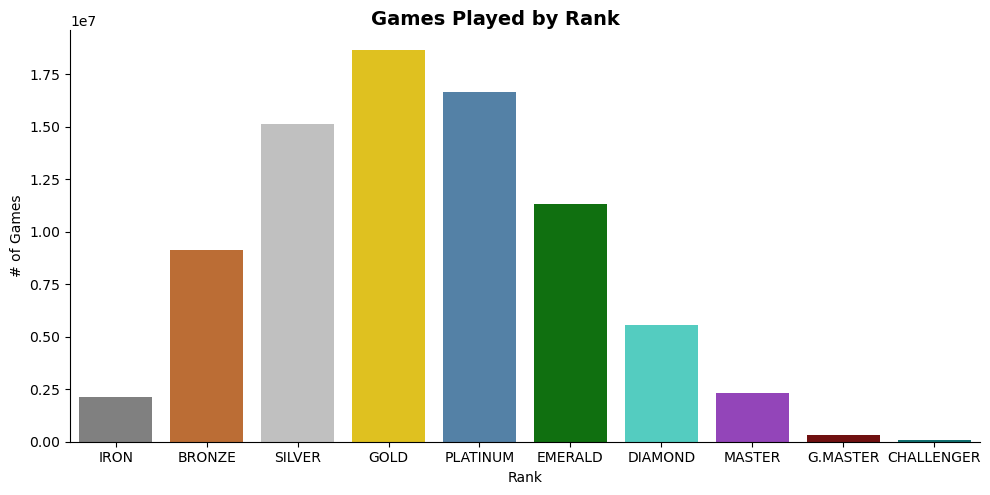

In [254]:
rankord = ['IRON', 'BRONZE', 'SILVER', 'GOLD', 'PLATINUM', 'EMERALD', 'DIAMOND', 'MASTER', 'G.MASTER', 'CHALLENGER']
palette2 = {'IRON':'gray', 
            'BRONZE':'chocolate', 
            'SILVER':'silver', 
            'GOLD':'gold', 
            'PLATINUM':'steelblue', 
            'EMERALD':'green', 
            'DIAMOND':'turquoise', 
            'MASTER':'darkorchid',
            'G.MASTER':'maroon', 
            'CHALLENGER':'teal',
           }

ax = sns.catplot(x= 'rank',y = 'games',data=leagueg, hue='rank', kind='bar',palette=palette2, order=rankord,height=5, aspect=2)
ax.figure.suptitle('Games Played by Rank', fontweight='bold', fontsize=14)
ax.set(xlabel='Rank', ylabel='# of Games')

plt.savefig('Games Across Ranks', dpi=300)

In [136]:
chall = league[league['rank']=='CHALLENGER']
diam = league[league['rank']=='DIAMOND']
bron = league[league['rank']=='BRONZE']

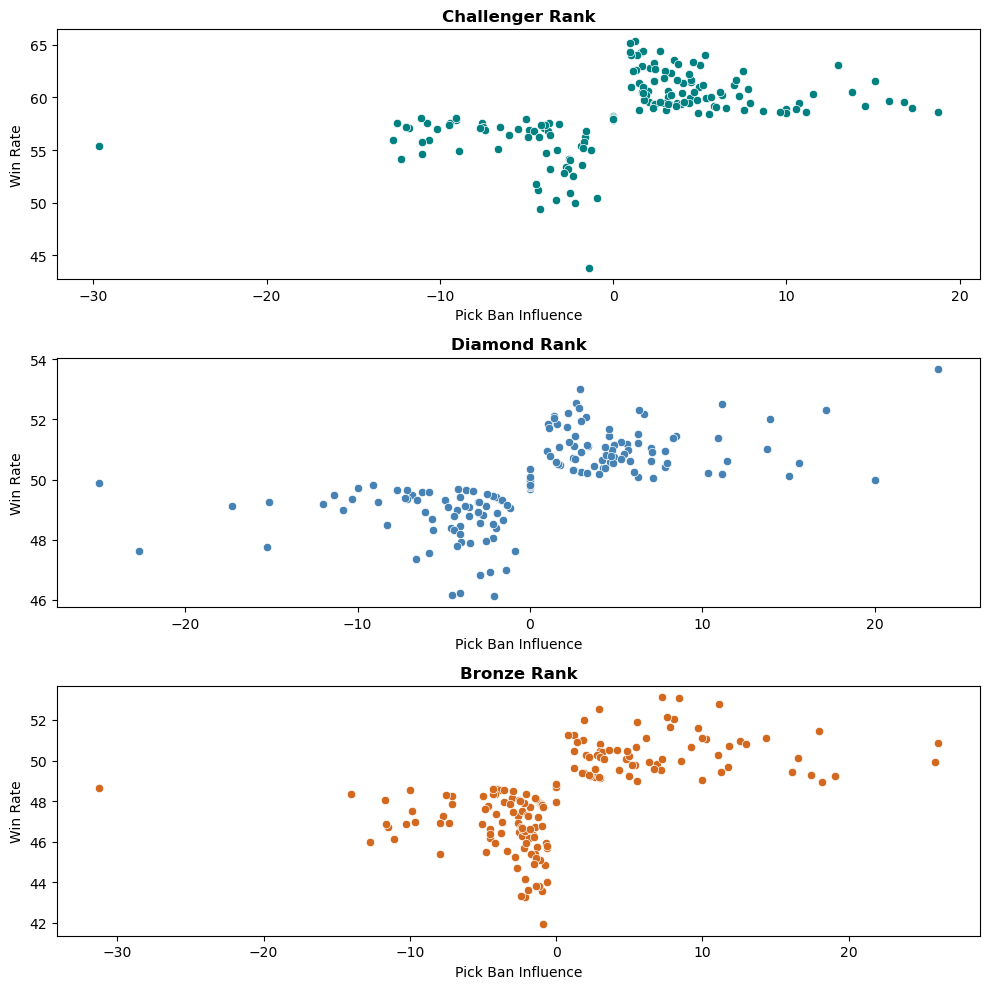

In [261]:
fig, ax = plt.subplots(3, 1, figsize=(10, 10))
ax1 = plt.subplot(3,1,1)
ax2 = plt.subplot(3,1,2)
ax3 = plt.subplot(3,1,3)

ax1 = sns.scatterplot(x='PBIno',y='wr',data=chall,ax=ax[0],color='teal')
ax2 = sns.scatterplot(x='PBIno',y='wr',data=diam,ax=ax[1],color='steelblue')
ax3 = sns.scatterplot(x='PBIno',y='wr',data=bron,ax=ax[2],color='chocolate')

ax1.set_title('Challenger Rank',fontweight='bold')
ax2.set_title('Diamond Rank',fontweight='bold')
ax3.set_title('Bronze Rank',fontweight='bold')

ax1.set(xlabel='Pick Ban Influence', ylabel='Win Rate')
ax2.set(xlabel='Pick Ban Influence', ylabel='Win Rate')
ax3.set(xlabel='Pick Ban Influence', ylabel='Win Rate')

fig.tight_layout()

plt.savefig('PBIvsWR.png', dpi=300)

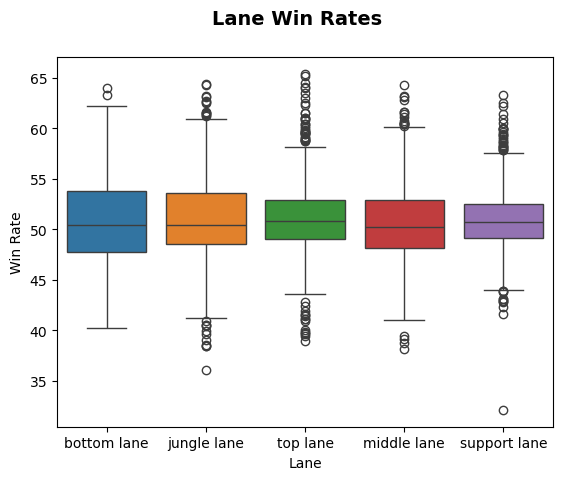

In [251]:
ax = sns.boxplot(x='lane',y='wr',data=league, hue='lane')
ax.figure.suptitle('Lane Win Rates', fontweight='bold', fontsize=14)
ax.set(xlabel='Lane', ylabel='Win Rate')
plt.savefig('Lane Win Rates.png', dpi=300)